# Optimzation of Quadratic Loss Function Approximation with D-Wave Anealer

In [49]:
import json
import os
import pickle as pkl

import dimod
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from dimod import BinaryQuadraticModel, ExactSolver
from dwave.samplers import SimulatedAnnealingSampler
from dwave.system import DWaveSampler, EmbeddingComposite
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.utils.data import DataLoader, TensorDataset
from time import perf_counter

## Idea

For the current parameter vector $w$, the batch loss is approximated locally by a second-order Taylor expansion:

$$
\mathcal{L}(w + \Delta) \approx \mathcal{L}(w) + g^\top \Delta + \frac{1}{2}\Delta^\top H\Delta,
$$

where $g = \nabla \mathcal{L}(w)$ and $H = \nabla^2 \mathcal{L}(w)$.

The annealer does not optimize the full continuous update directly. Instead, for a selected subset of parameters, it chooses binary variables $z_i \in \{0,1\}$ that encode the sign of a fixed-size step:

$$
\Delta_i = \eta(2z_i - 1),
$$

so $z_i = 1$ means a $+\eta$ step and $z_i = 0$ means a $-\eta$ step. Substituting this into the quadratic model turns the local optimization problem into a QUBO/BQM:

$$
E(z) = \sum_i a_i z_i + \sum_{i<j} b_{ij} z_i z_j + c.
$$

The annealer minimizes $E(z)$, then the proposed update is applied to the network parameters and accepted only if the true loss decreases.

## Net Class

In [ ]:
class QuadraticMLP(nn.Module):


    """A simple feedforward neural network with quadratic interactions between the layers."""

    def __init__(
        self,
        input_dim: int,
        hidden_dim: list[int],
        output_dim: int,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim

        layer_dims = [input_dim, *hidden_dim, output_dim]
        modules = []
        for index in range(len(layer_dims) - 1):
            modules.append(nn.Linear(layer_dims[index], layer_dims[index + 1]))
            if index < len(layer_dims) - 2:
                modules.append(nn.Tanh())

        self.network = nn.Sequential(*modules)

    def forward(self, 
                x: torch.Tensor,
    ) -> torch.Tensor:
        return self.network(x)

## Loading sample Iris data for training

In [17]:
# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.FloatTensor(X)
y = torch.LongTensor(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [18]:
training_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(training_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Training samples: {len(training_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 105
Test samples: 45


## Optimizer

In [ ]:
class QuadraticAnnealingOptimizer:

    """An optimizer that uses a quadratic approximation of the loss landscape to construct a binary quadratic model, 
    which is then optimized using a quantum annealer or a classical sampler. The optimizer selects a subset of parameters 
    based on the magnitude of their gradients or randomly, and constructs a BQM that approximates the loss landscape in 
    the neighborhood of the current parameters. The BQM is then optimized using the provided sampler, and the candidate 
    parameters are evaluated on the loss function. If the candidate parameters yield a lower loss, they are accepted; 
    otherwise, the optimizer reverts to the original parameters.
    """

    def __init__(
        self,
        sampler,
        model: nn.Module,
        device: str = "cpu",
        subset_size: int = 12,
        step_size: float = 0.05,
        num_reads: int = 100,
        selection: str = "topk",
    ):
        self.sampler = sampler
        self.model = model
        self.device = torch.device(device)
        self.subset_size = subset_size
        self.step_size = step_size
        self.num_reads = num_reads
        self.selection = selection

    def _selected_indices(self, grad_vec: torch.Tensor) -> torch.Tensor:

        """
        Function to select the subset of indices that will be included in an optimization step.
        """
        block_size = min(self.subset_size, grad_vec.numel())
        if self.selection == "topk":
            return torch.topk(grad_vec.abs(), k=block_size).indices
        if self.selection == "random":
            return torch.randperm(grad_vec.numel(), device=grad_vec.device)[:block_size]
        raise ValueError("selection must be either 'topk' or 'random'")

    def quadratic_model(self, 
                        loss: torch.Tensor,
    ) -> list[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Function to compute the quadratic approximation of the loss landscape in the neighborhood of the current parameters.
        """
        params = [param for param in self.model.parameters() if param.requires_grad]
        grads = torch.autograd.grad(loss, params, create_graph=True)
        grad_vec = parameters_to_vector(grads)
        selected_indices = self._selected_indices(grad_vec)
        grad_block = grad_vec[selected_indices]

        hessian_block = torch.zeros(
            (selected_indices.numel(), selected_indices.numel()),
            device=self.device,
        )

        for row_index, param_index in enumerate(selected_indices):
            second_grads = torch.autograd.grad(
                grad_vec[param_index],
                params,
                retain_graph=row_index + 1 < selected_indices.numel(),
            )
            second_vec = parameters_to_vector(second_grads)
            hessian_block[row_index] = second_vec[selected_indices]

        hessian_block = 0.5 * (hessian_block + hessian_block.T) # Hermitization
        return (grad_vec.detach(), 
                selected_indices.detach(), 
                grad_block.detach(), 
                hessian_block.detach(),
                )

    def build_bqm(
        self,
        selected_indices: torch.Tensor,
        grad_block: torch.Tensor,
        hessian_block: torch.Tensor,
    ) -> BinaryQuadraticModel:
        """ 
        Function to build a binary quadratic model from the selected gradient and Hessian blocks. 
        """
        step_sq = self.step_size ** 2
        linear = {}
        quadratic = {}
        offset = 0.0

        for local_index, global_index in enumerate(selected_indices.tolist()):
            gradient_value = float(grad_block[local_index].item())
            curvature_value = float(hessian_block[local_index, local_index].item())
            linear[int(global_index)] = 2.0 * self.step_size * gradient_value
            offset += -self.step_size * gradient_value
            offset += 0.5 * step_sq * curvature_value

        for left in range(selected_indices.numel()):
            for right in range(left + 1, selected_indices.numel()):
                coupling = float(hessian_block[left, right].item())
                if abs(coupling) < 1e-12:
                    continue

                left_index = int(selected_indices[left].item())
                right_index = int(selected_indices[right].item())
                linear[left_index] = linear.get(left_index, 0.0) - 2.0 * step_sq * coupling
                linear[right_index] = linear.get(right_index, 0.0) - 2.0 * step_sq * coupling
                quadratic[(left_index, right_index)] = 4.0 * step_sq * coupling
                offset += step_sq * coupling

        return BinaryQuadraticModel(linear, quadratic, offset, dimod.BINARY)

    def sample_bqm(self, 
                   bqm: BinaryQuadraticModel,
    ) -> dimod.SampleSet:
        """ 
        Sampleing from BQM according to chosen sampler.
        """
        if isinstance(self.sampler, ExactSolver):
            return self.sampler.sample(bqm)
        return self.sampler.sample(bqm, num_reads=self.num_reads)

    def step(self, 
             features: torch.Tensor, 
             targets: torch.Tensor, 
             loss_fn: nn.Module,
    ) -> dict[str, float | bool | int]:
        """ 
        Single optimization step.
        """
        self.model.zero_grad(set_to_none=True)
        logits = self.model(features)
        loss = loss_fn(logits, targets)

        current_params = parameters_to_vector(self.model.parameters()).detach().clone()
        _, selected_indices, grad_block, hessian_block = self.quadratic_model(loss)
        bqm = self.build_bqm(selected_indices, grad_block, hessian_block)
        response = self.sample_bqm(bqm)

        delta = torch.zeros_like(current_params)
        for parameter_index in selected_indices.tolist():
            bit_value = response.first.sample[int(parameter_index)]
            delta[int(parameter_index)] = self.step_size if bit_value else -self.step_size

        with torch.no_grad():
            candidate_params = current_params + delta.to(current_params.device)
            vector_to_parameters(candidate_params, self.model.parameters())
            candidate_loss = float(loss_fn(self.model(features), targets).item())

            if candidate_loss > float(loss.item()):
                vector_to_parameters(current_params, self.model.parameters())
                accepted = False
                effective_loss = float(loss.item())
            else:
                accepted = True
                effective_loss = candidate_loss

        return {
            "loss": effective_loss,
            "quadratic_energy": float(response.first.energy),
            "accepted": accepted,
            "selected_variables": int(selected_indices.numel()),
        }

## Training

In [41]:
loss_fn = nn.CrossEntropyLoss()
model = QuadraticMLP(4, [16, 8], 3)
classical_device = "cpu" # TODO: Ogranąc dlaczgo cuda nie działa 

def build_sampler(mode: str = "simulated"):
    normalized_mode = mode.lower()

    if normalized_mode == "dwave":
        try:
            return EmbeddingComposite(DWaveSampler()), "dwave"
        except Exception as exc:
            print(f"Falling back to simulated annealing because the QPU is unavailable: {exc}")
            return SimulatedAnnealingSampler(), "simulated"

    if normalized_mode == "exact":
        return ExactSolver(), "exact"

    if normalized_mode == "simulated":
        return SimulatedAnnealingSampler(), "simulated"

    raise ValueError("mode must be one of: simulated, exact, dwave")

sampler, sampler_name = build_sampler(mode="simulated")
print(f"Using sampler: {sampler_name}")

Using sampler: simulated


In [42]:
def evaluate(
    model: nn.Module,
    data_loader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
    ):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for features, targets in data_loader:
            features = features.to(device)
            targets = targets.to(device)
            logits = model(features)
            total_loss += float(loss_fn(logits, targets).item()) * targets.size(0)
            total_correct += int((logits.argmax(dim=1) == targets).sum().item())
            total_examples += int(targets.size(0))

    average_loss = total_loss / total_examples
    accuracy = total_correct / total_examples
    return average_loss, accuracy

In [68]:
def train_dwave(
    model: QuadraticMLP,
    train_loader: DataLoader,
    test_loader: DataLoader,
    loss_fn: nn.Module,
    c_device: str,
    sampler,
    epochs: int,
    subset_size: int = 12,
    step_size: float = 0.05,
    num_reads: int = 100,
    ):
    device = torch.device(c_device)
    model.to(device)

    annealer = QuadraticAnnealingOptimizer(
        sampler=sampler,
        model=model,
        device=device,
        subset_size=subset_size,
        step_size=step_size,
        num_reads=num_reads,
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_quadratic_energy": [],
        "acceptance_rate": [],
        "test_loss": [],
        "test_accuracy": [],
    }

    os.makedirs("models", exist_ok=True)
    os.makedirs("stats", exist_ok=True)

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        batch_energies = []
        accepted_steps = 0

        for features, targets in train_loader:
            features = features.to(device)
            targets = targets.to(device)
            step_info = annealer.step(features, targets, loss_fn)
            batch_losses.append(step_info["loss"])
            batch_energies.append(step_info["quadratic_energy"])
            accepted_steps += int(step_info["accepted"])

        train_loss, train_accuracy = evaluate(model, train_loader, loss_fn, device)
        test_loss, test_accuracy = evaluate(model, test_loader, loss_fn, device)
        acceptance_rate = accepted_steps / len(train_loader)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["train_quadratic_energy"].append(sum(batch_energies) / len(batch_energies))
        history["acceptance_rate"].append(acceptance_rate)
        history["test_loss"].append(test_loss)
        history["test_accuracy"].append(test_accuracy)

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_accuracy:.3f} | "
                f"test_loss={test_loss:.4f} | "
                f"test_acc={test_accuracy:.3f} | "
                f"acceptance={acceptance_rate:.2f}"
            )

    torch.save(model.state_dict(), "models/quadratic_mlp_annealer_state_dict.pth")
    with open("models/config.json", "w") as file:
        json.dump(
            {
                "input_dim": model.input_dim,
                "hidden_dim": model.hidden_dim,
                "output_dim": model.output_dim,
                "sampler": sampler_name,
                "subset_size": subset_size,
                "step_size": step_size,
                "num_reads": num_reads,
                "epochs": epochs,
            },
            file,
            indent=2,
        )
    os.makedirs("stats/annealer", exist_ok=True)
    for stat_name, values in history.items():
        with open(f"stats/annealer/{stat_name}.pkl", "wb") as file:
            pkl.dump(values, file)

    return history

In [69]:
history = train_dwave(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    c_device=classical_device,
    sampler=sampler,
    epochs=30,
    subset_size=24,
    step_size=0.05,
    num_reads=200,
    )

Epoch 000 | train_loss=0.1080 | train_acc=0.971 | test_loss=0.2927 | test_acc=0.933 | acceptance=1.00
Epoch 005 | train_loss=0.0637 | train_acc=0.981 | test_loss=0.3073 | test_acc=0.956 | acceptance=1.00
Epoch 010 | train_loss=0.0912 | train_acc=0.981 | test_loss=0.2313 | test_acc=0.956 | acceptance=1.00
Epoch 015 | train_loss=0.1377 | train_acc=0.981 | test_loss=0.1985 | test_acc=0.978 | acceptance=1.00
Epoch 020 | train_loss=0.0573 | train_acc=0.990 | test_loss=0.4826 | test_acc=0.956 | acceptance=1.00
Epoch 025 | train_loss=0.1089 | train_acc=0.981 | test_loss=0.5327 | test_acc=0.956 | acceptance=1.00
Epoch 029 | train_loss=0.1318 | train_acc=0.981 | test_loss=0.2205 | test_acc=0.956 | acceptance=1.00


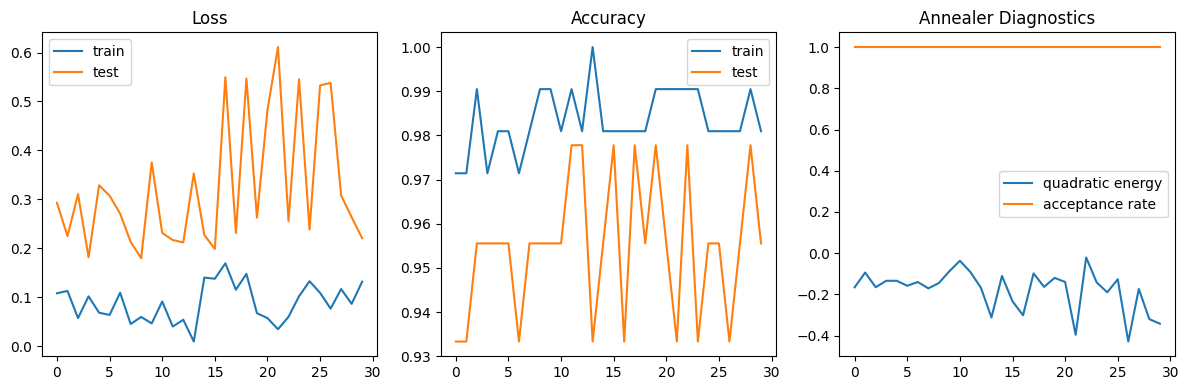

In [70]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["train_accuracy"], label="train")
plt.plot(history["test_accuracy"], label="test")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history["train_quadratic_energy"], label="quadratic energy")
plt.plot(history["acceptance_rate"], label="acceptance rate")
plt.title("Annealer Diagnostics")
plt.legend()

plt.tight_layout()
plt.show()

In [71]:
print(f"Final train accuracy: {history['train_accuracy'][-1]:.3f}")
print(f"Final test accuracy: {history['test_accuracy'][-1]:.3f}")
print(f"Final acceptance rate: {history['acceptance_rate'][-1]:.2f}")

Final train accuracy: 0.981
Final test accuracy: 0.956
Final acceptance rate: 1.00


# Classical optimization for benchmarking

## Optimization using Adam optimizaer

In [74]:
def train_adam(
    model: QuadraticMLP,
    train_loader: DataLoader,
    test_loader: DataLoader,
    loss_fn: nn.Module,
    c_device: str,
    epochs: int,
    learning_rate: float = 1e-2,
    weight_decay: float = 0.0,
    ):
    """ 
    Optimization using Adam optimizer.
    """
    device = torch.device(c_device)
    model.to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": [],
    }

    start_time = perf_counter()

    for epoch in range(epochs):
        model.train()

        for features, targets in train_loader:
            features = features.to(device)
            targets = targets.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(features)
            loss = loss_fn(logits, targets)
            loss.backward()
            optimizer.step()

        train_loss, train_accuracy = evaluate(model, train_loader, loss_fn, device)
        test_loss, test_accuracy = evaluate(model, test_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["test_loss"].append(test_loss)
        history["test_accuracy"].append(test_accuracy)

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_accuracy:.3f} | "
                f"test_loss={test_loss:.4f} | "
                f"test_acc={test_accuracy:.3f}"
            )

    torch.save(model.state_dict(), "models/quadratic_mlp_adam_state_dict.pth")
    with open("models/config_adam.json", "w") as file:
        json.dump(
            {
                "input_dim": model.input_dim,
                "hidden_dim": model.hidden_dim,
                "output_dim": model.output_dim,
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
                "epochs": epochs,
            },
            file,
            indent=2,
        )
    os.makedirs("stats/adam", exist_ok=True)
    for stat_name, values in history.items():
        with open(f"stats/adam/{stat_name}_adam.pkl", "wb") as file:
            pkl.dump(values, file)

    history["training_time_sec"] = perf_counter() - start_time
    return history

In [75]:
adam_model = QuadraticMLP(
    input_dim=model.input_dim,
    hidden_dim=model.hidden_dim,
    output_dim=model.output_dim,
)
adam_history = train_adam(
    model=adam_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    c_device=classical_device,
    epochs=30,
    learning_rate=1e-2,
)

print(f"Adam final train accuracy: {adam_history['train_accuracy'][-1]:.3f}")
print(f"Adam final test accuracy: {adam_history['test_accuracy'][-1]:.3f}")
print(f"Adam training time [s]: {adam_history['training_time_sec']:.3f}")

Epoch 000 | train_loss=0.9189 | train_acc=0.667 | test_loss=0.9339 | test_acc=0.667
Epoch 005 | train_loss=0.2789 | train_acc=0.933 | test_loss=0.3661 | test_acc=0.844
Epoch 010 | train_loss=0.1044 | train_acc=0.981 | test_loss=0.1733 | test_acc=0.956
Epoch 015 | train_loss=0.0602 | train_acc=0.981 | test_loss=0.1289 | test_acc=0.933
Epoch 020 | train_loss=0.0422 | train_acc=0.990 | test_loss=0.1360 | test_acc=0.933
Epoch 025 | train_loss=0.0345 | train_acc=0.990 | test_loss=0.1999 | test_acc=0.911
Epoch 029 | train_loss=0.0267 | train_acc=1.000 | test_loss=0.1663 | test_acc=0.911
Adam final train accuracy: 1.000
Adam final test accuracy: 0.911
Adam training time [s]: 0.174


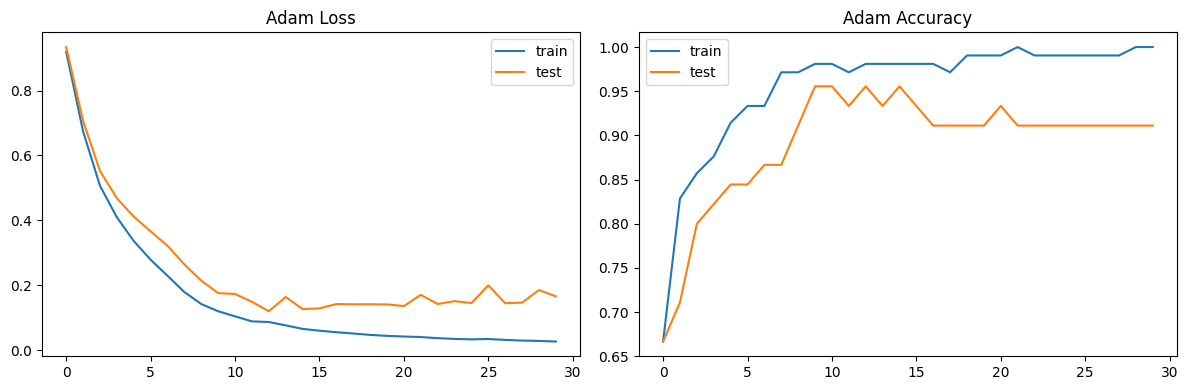

In [76]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(adam_history["train_loss"], label="train")
plt.plot(adam_history["test_loss"], label="test")
plt.title("Adam Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(adam_history["train_accuracy"], label="train")
plt.plot(adam_history["test_accuracy"], label="test")
plt.title("Adam Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Optimization using LBFGS-style second-order optimizer

In [ ]:
def loader_to_full_batch(
    data_loader: DataLoader,
    device: torch.device,
) -> tuple[torch.Tensor, torch.Tensor]:
    feature_batches = []
    target_batches = []

    for features, targets in data_loader:
        feature_batches.append(features.to(device))
        target_batches.append(targets.to(device))

    return torch.cat(feature_batches, dim=0), torch.cat(target_batches, dim=0)

In [78]:
def gradients_to_vector(model: nn.Module) -> torch.Tensor:
    gradient_tensors = []

    for parameter in model.parameters():
        if parameter.grad is None:
            gradient_tensors.append(torch.zeros_like(parameter))
        else:
            gradient_tensors.append(parameter.grad)

    return parameters_to_vector(gradient_tensors)

In [79]:
def vector_to_gradients(
    grad_vector: torch.Tensor,
    model: nn.Module,
) -> None:
    offset = 0

    for parameter in model.parameters():
        num_parameters = parameter.numel()
        grad_slice = grad_vector[offset:offset + num_parameters].view_as(parameter)

        if parameter.grad is None:
            parameter.grad = grad_slice.detach().clone()
        else:
            parameter.grad.copy_(grad_slice)

        offset += num_parameters

In [84]:
def train_bfgs(
    model: QuadraticMLP,
    train_loader: DataLoader,
    test_loader: DataLoader,
    loss_fn: nn.Module,
    c_device: str,
    epochs: int,
    mode: str = "full",
    top_k: int = 24,
    learning_rate: float = 1.0,
    max_iter: int = 20,
    history_size: int = 10,
) -> dict[str, float | list[float] | list[int] | str]:
    device = torch.device(c_device)
    model.to(device)

    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=learning_rate,
        max_iter=max_iter,
        history_size=history_size,
        line_search_fn="strong_wolfe",
    )

    normalized_mode = mode.lower()
    if normalized_mode not in {"full", "topk"}:
        raise ValueError("mode must be one of: full, topk")

    total_parameters = int(sum(parameter.numel() for parameter in model.parameters()))
    history = {
        "mode": normalized_mode,
        "train_loss": [],
        "train_accuracy": [],
        "test_loss": [],
        "test_accuracy": [],
        "selected_variables": [],
    }

    start_time = perf_counter()

    for epoch in range(epochs):
        model.train()
        epoch_selected_variables = []

        for features, targets in train_loader:
            features = features.to(device)
            targets = targets.to(device)
            selected_indices = None
            parameter_mask = None

            if normalized_mode == "topk":
                model.zero_grad(set_to_none=True)
                batch_loss = loss_fn(model(features), targets)
                batch_loss.backward()
                grad_vector = gradients_to_vector(model)
                block_size = min(top_k, grad_vector.numel())
                selected_indices = torch.topk(grad_vector.abs(), k=block_size).indices
                parameter_mask = torch.zeros_like(grad_vector)
                parameter_mask[selected_indices] = 1.0
                epoch_selected_variables.append(int(block_size))
            else:
                epoch_selected_variables.append(total_parameters)

            parameters_before_step = parameters_to_vector(model.parameters()).detach().clone()

            def closure() -> torch.Tensor:
                optimizer.zero_grad(set_to_none=True)
                logits = model(features)
                loss = loss_fn(logits, targets)
                loss.backward()

                if parameter_mask is not None:
                    masked_grad_vector = gradients_to_vector(model) * parameter_mask
                    vector_to_gradients(masked_grad_vector, model)

                return loss

            optimizer.step(closure)

            if selected_indices is not None:
                parameters_after_step = parameters_to_vector(model.parameters()).detach().clone()
                constrained_parameters = parameters_before_step.clone()
                constrained_parameters[selected_indices] = parameters_after_step[selected_indices]
                vector_to_parameters(constrained_parameters, model.parameters())

        train_loss, train_accuracy = evaluate(model, train_loader, loss_fn, device)
        test_loss, test_accuracy = evaluate(model, test_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["test_loss"].append(test_loss)
        history["test_accuracy"].append(test_accuracy)
        history["selected_variables"].append(
            int(sum(epoch_selected_variables) / len(epoch_selected_variables))
        )

        if epoch % 5 == 0 or epoch == epochs - 1:
            print(
                f"[{normalized_mode}] Epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"train_acc={train_accuracy:.3f} | "
                f"test_loss={test_loss:.4f} | "
                f"test_acc={test_accuracy:.3f} | "
                f"selected={history['selected_variables'][-1]}"
            )

    history["training_time_sec"] = perf_counter() - start_time
    return history

In [85]:
bfgs_full_model = QuadraticMLP(
    input_dim=model.input_dim,
    hidden_dim=model.hidden_dim,
    output_dim=model.output_dim,
)
bfgs_full_history = train_bfgs(
    model=bfgs_full_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    c_device=classical_device,
    epochs=30,
    mode="full",
)

bfgs_topk_model = QuadraticMLP(
    input_dim=model.input_dim,
    hidden_dim=model.hidden_dim,
    output_dim=model.output_dim,
)
bfgs_topk_history = train_bfgs(
    model=bfgs_topk_model,
    train_loader=train_loader,
    test_loader=test_loader,
    loss_fn=loss_fn,
    c_device=classical_device,
    epochs=30,
    mode="topk",
    top_k=24,
)

print(f"BFGS-style full final train accuracy: {bfgs_full_history['train_accuracy'][-1]:.3f}")
print(f"BFGS-style full final test accuracy: {bfgs_full_history['test_accuracy'][-1]:.3f}")
print(f"BFGS-style full training time [s]: {bfgs_full_history['training_time_sec']:.3f}")
print(f"BFGS-style top-k final train accuracy: {bfgs_topk_history['train_accuracy'][-1]:.3f}")
print(f"BFGS-style top-k final test accuracy: {bfgs_topk_history['test_accuracy'][-1]:.3f}")
print(f"BFGS-style top-k training time [s]: {bfgs_topk_history['training_time_sec']:.3f}")

[full] Epoch 000 | train_loss=1.0510 | train_acc=0.962 | test_loss=6.9793 | test_acc=0.867 | selected=243
[full] Epoch 005 | train_loss=0.3986 | train_acc=0.971 | test_loss=2.7782 | test_acc=0.889 | selected=243
[full] Epoch 010 | train_loss=0.6692 | train_acc=0.952 | test_loss=3.9928 | test_acc=0.822 | selected=243
[full] Epoch 015 | train_loss=3.3826 | train_acc=0.838 | test_loss=3.7170 | test_acc=0.711 | selected=243
[full] Epoch 020 | train_loss=26.0656 | train_acc=0.562 | test_loss=19.4897 | test_acc=0.533 | selected=243
[full] Epoch 025 | train_loss=4.2479 | train_acc=0.714 | test_loss=0.4320 | test_acc=0.778 | selected=243
[full] Epoch 029 | train_loss=4.0521 | train_acc=0.714 | test_loss=0.3773 | test_acc=0.778 | selected=243
[topk] Epoch 000 | train_loss=9.6213 | train_acc=0.838 | test_loss=14.0608 | test_acc=0.733 | selected=24
[topk] Epoch 005 | train_loss=1.8430 | train_acc=0.962 | test_loss=5.2153 | test_acc=0.844 | selected=24
[topk] Epoch 010 | train_loss=0.2920 | train_

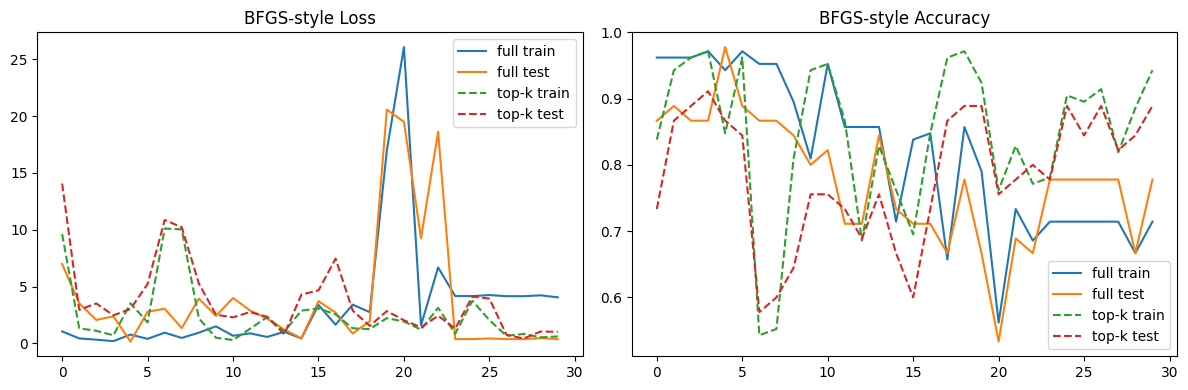

In [86]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(bfgs_full_history["train_loss"], label="full train")
plt.plot(bfgs_full_history["test_loss"], label="full test")
plt.plot(bfgs_topk_history["train_loss"], label="top-k train", linestyle="--")
plt.plot(bfgs_topk_history["test_loss"], label="top-k test", linestyle="--")
plt.title("BFGS-style Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(bfgs_full_history["train_accuracy"], label="full train")
plt.plot(bfgs_full_history["test_accuracy"], label="full test")
plt.plot(bfgs_topk_history["train_accuracy"], label="top-k train", linestyle="--")
plt.plot(bfgs_topk_history["test_accuracy"], label="top-k test", linestyle="--")
plt.title("BFGS-style Accuracy")
plt.legend()

plt.tight_layout()
plt.show()